In [1]:
import pandas as pd
import geopandas
import hdbscan
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import silhouette_score
import numpy as np
from shapely import wkt
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


### **0. Prepare the data**

#### 0.1 Loading data

In [2]:
file_path = '/content/drive/MyDrive/CUSP-GX 7103 CAPSTONE/CAPSTONE WORK PROGRESS/Output/Cleaned_POI/SafeGraph_London.csv'
POI = pd.read_csv(file_path)

# Rename PRIMARY_CATEGORY to PARENT_CATEGORY as requested
if 'PRIMARY_CATEGORY' in POI.columns:
    POI.rename(columns={'PRIMARY_CATEGORY': 'PARENT_CATEGORY'}, inplace=True)
    print("Renamed 'PRIMARY_CATEGORY' to 'PARENT_CATEGORY' in POI DataFrame.")

# Display shape and head of the original POI DataFrame as per previous cell behavior
print(POI.shape)
display(POI.head())

Renamed 'PRIMARY_CATEGORY' to 'PARENT_CATEGORY' in POI DataFrame.
(154077, 12)


,PLACEKEY,LOCATION_NAME,POLYGON_CLASS,PARENT_PLACEKEY,REGION,LATITUDE,LONGITUDE,PARENT_CATEGORY,CHILD_CATEGORY,WKT_AREA_SQ_METERS,geometry,NAICS_CODE
0,zzy-24n@4hq-8mp-9xq,House Party,SHARED_POLYGON,NaN,Greater London,51.513590,-0.136611,Food and Drinks,Bars & Pubs,273.0,"MULTIPOLYGON (((1.1848427408 51.0803720305, 1....",722410
1,238-222@4hq-8mp-9xq,Milk & Honey,SHARED_POLYGON,NaN,Greater London,51.513602,-0.136624,Food and Drinks,Bars & Pubs,273.0,"MULTIPOLYGON (((1.1848427408 51.0803720305, 1....",722410
2,22j-224@4hq-8mp-9xq,Social Eating House,SHARED_POLYGON,NaN,Greater London,51.513567,-0.136595,Food and Drinks,Dining,273.0,"MULTIPOLYGON (((1.1848427408 51.0803720305, 1....",722511
3,zzy-25m@4hq-8mp-9xq,V7 Asset Mangement,SHARED_POLYGON,NaN,Greater London,51.513568,-0.136596,Services,Real Estate Services,273.0,"MULTIPOLYGON (((1.1848427408 51.0803720305, 1....",531210
4,zzy-222@4hh-zwf-skf,Plan-it travel excursions - Weekend Breaks Orp...,OWNED_POLYGON,NaN,Greater London,51.357652,0.105211,Services,Transportation Services,124.0,"POLYGON ((0.105300089221121 51.3575915044898, ...",485310


### **1. Micro-Agglomeration Zones (MAZ)**

#### 1.1 HDBSCAN Clustering

In [3]:
# Construct coordinates
coordinates = POI[['LATITUDE', 'LONGITUDE']].values

# Train the model with parameters:
# min_cluster_size=120
# min_samples=15
# metric='haversine'
clusterer = hdbscan.HDBSCAN(min_cluster_size=100, min_samples=15, metric='haversine')
print("HDBSCAN clusterer initialized.")

# Add clustering labels to each point
cluster_labels = clusterer.fit_predict(coordinates)
print("HDBSCAN model fitted and labels predicted.")

POI['cluster_label'] = cluster_labels
print("Cluster labels added to POI DataFrame.")

HDBSCAN clusterer initialized.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


HDBSCAN model fitted and labels predicted.
Cluster labels added to POI DataFrame.


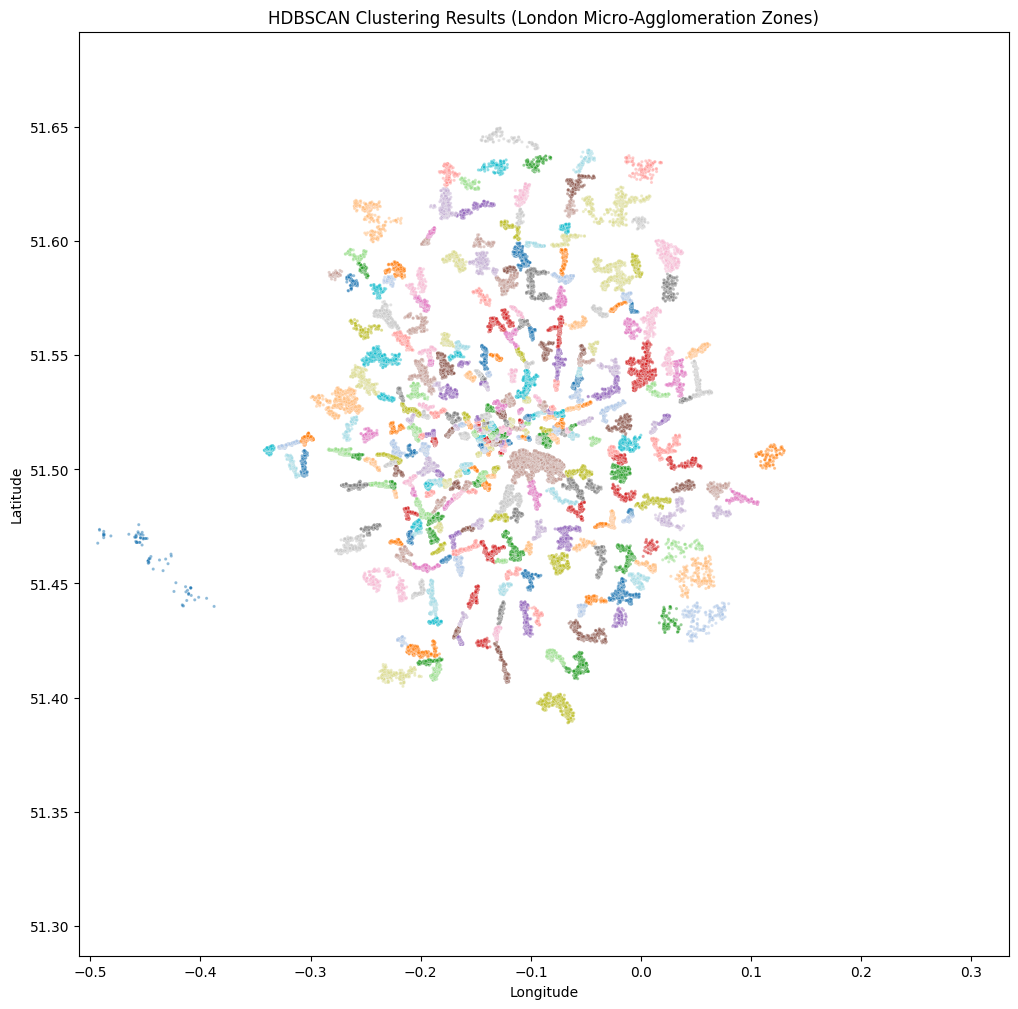

In [ ]:
# Explicitly set the 'sans-serif' font list to common, known-to-exist English fonts
# This ensures that matplotlib doesn't try to find 'SimHei' or any other specific font that isn't present
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif']
# Also ensure unicode_minus is true for English plotting
plt.rcParams['axes.unicode_minus'] = True

# Filter out noise points (cluster label -1)
clustered_pois = POI[POI['cluster_label'] != -1].copy()

# Re-create point geometries from LATITUDE and LONGITUDE to ensure GeoDataFrame validity
clustered_pois['geometry'] = geopandas.points_from_xy(clustered_pois['LONGITUDE'], clustered_pois['LATITUDE'])

# Create a GeoDataFrame for visualization, ensuring the geometry column contains valid shapely point objects
clustered_gdf = geopandas.GeoDataFrame(clustered_pois, geometry='geometry', crs="EPSG:4326")

# Use warnings.catch_warnings to suppress other UserWarnings specifically for the plotting part
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning) # This should cover any *other* UserWarnings generated within this block

    plt.figure(figsize=(12, 12)) # Increased figsize from (10,10) to (12,12)

    # Plot each cluster with different colors
    # Using 'tab20' palette and hiding the legend due to potentially many clusters
    sns.scatterplot(
        x=clustered_gdf.geometry.x,
        y=clustered_gdf.geometry.y,
        hue=clustered_gdf['cluster_label'],
        palette='tab20',
        s=5, alpha=0.5,
        legend=False, # Hide legend as too many clusters can make it cluttered
        ax=plt.gca()
    )

    # Set limits for Great London (approximate coordinates)
    plt.xlim(-0.5103, 0.3340)  # Longitude limits
    plt.ylim(51.2868, 51.6919)  # Latitude limits

    plt.title('HDBSCAN Clustering Results (London Micro-Agglomeration Zones)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

In [ ]:
POI['cluster_label'].nunique()

353

In [ ]:
output_dir = '/content/drive/MyDrive/CUSP-GX 7103 CAPSTONE/CAPSTONE WORK PROGRESS/Output/GeoJSON'
output_filename = 'london_maz_hdbscan.geojson'
output_path = os.path.join(output_dir, output_filename)

os.makedirs(output_dir, exist_ok=True)

if 'clustered_gdf' in locals() or 'clustered_gdf' in globals():
    clustered_gdf.to_file(output_path, driver='GeoJSON')
    print(f"Succeed! {output_path}")
else:
    print("Error! clustered_gdf not found or not a valid GeoDataFrame.")

Succeed! /content/drive/MyDrive/CUSP-GX 7103 CAPSTONE/CAPSTONE WORK PROGRESS/Output/GeoJSON/london_maz_hdbscan.geojson


#### 1.3 Visualize Convex Hulls

In [ ]:
cluster_hulls = clustered_gdf.dissolve(by='cluster_label', aggfunc='first').reset_index()
cluster_hulls['geometry'] = cluster_hulls.geometry.convex_hull

print("Convex hulls calculated for each cluster.")
# display(cluster_hulls.head())

Convex hulls calculated for each cluster.


In [ ]:
output_dir = '/content/drive/MyDrive/CUSP-GX 7103 CAPSTONE/CAPSTONE WORK PROGRESS/Output/GeoJSON'
output_filename = 'london_maz_convexhulls.geojson'
output_path = os.path.join(output_dir, output_filename)

os.makedirs(output_dir, exist_ok=True)

cluster_hulls.to_file(output_path, driver='GeoJSON')
print(f"Convex hulls saved successfully to {output_path}")

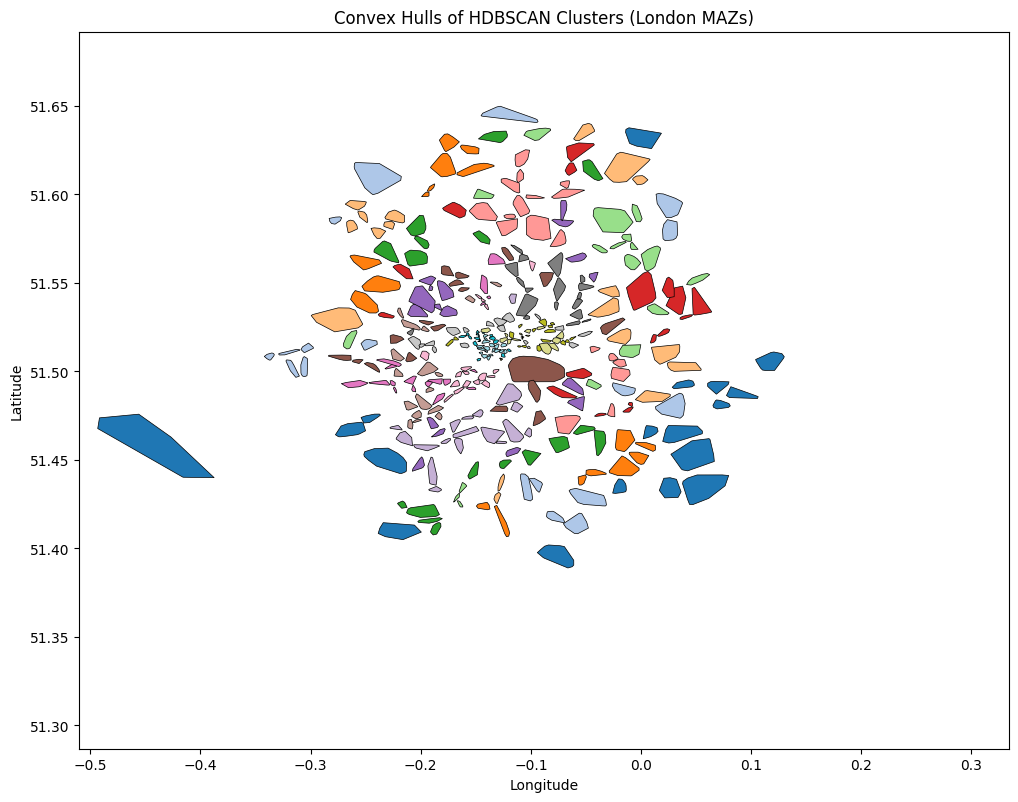

In [ ]:
# Ensure font settings are consistent
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = True

plt.figure(figsize=(12, 12))

# Plot the convex hulls, colored by cluster_label
# Using 'tab20' palette and hiding the legend due to potentially many clusters
cluster_hulls.plot(
    column='cluster_label',
    cmap='tab20',
    ax=plt.gca(),
    edgecolor='black',
    linewidth=0.5,
    legend=False
)

# Set limits for Great London (approximate coordinates) for consistency with previous plots
plt.xlim(-0.5103, 0.3340)  # Longitude limits
plt.ylim(51.2868, 51.6919)  # Latitude limits

plt.title('Convex Hulls of HDBSCAN Clusters (London MAZs)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

#### 1.4 Silhouette Score

In [ ]:
# Filter the Noise（cluster_label != -1）
valid_samples_mask = POI['cluster_label'] != -1
valid_coordinates = coordinates[valid_samples_mask]
valid_cluster_labels = POI.loc[valid_samples_mask, 'cluster_label']

# Start Calculation
if len(np.unique(valid_cluster_labels)) > 1 and len(valid_coordinates) > 1:

    radians_coordinates = np.radians(valid_coordinates)

    silhouette_avg = silhouette_score(radians_coordinates, valid_cluster_labels, metric='haversine')
    print(f"Silhouette Score: {silhouette_avg}")
else:
    print("Insufficient data points or clusters to compute the Silhouette Score.")

Silhouette Score: 0.4903356062149397


In [ ]:
# Calculate the % of Noise
noise_points_count = (POI['cluster_label'] == -1).sum()

total_pois_count = len(POI)

noise_percentage = (noise_points_count / total_pois_count) * 100

print(f"{noise_percentage:.2f}%")

37.48%


### **2. Co-location Network**

#### 2.1  Spearman Rank

In [5]:
clustered_poi_data = POI[POI['cluster_label'] != -1].copy()

# Calculate total counts for each CHILD_CATEGORY across all clusters
category_total_counts_df = clustered_poi_data.groupby('CHILD_CATEGORY').size().reset_index(name='Total Count')

# Create a mapping from CHILD_CATEGORY to its corresponding PARENT_CATEGORY
category_mapping = clustered_poi_data.drop_duplicates(subset=['CHILD_CATEGORY'])[['CHILD_CATEGORY', 'PARENT_CATEGORY']]
category_mapping = dict(zip(category_mapping['CHILD_CATEGORY'], category_mapping['PARENT_CATEGORY']))

print("clustered_poi_data, category_total_counts_df, and category_mapping prepared.")
display(category_total_counts_df.head())


clustered_poi_data, category_total_counts_df, and category_mapping prepared.


,CHILD_CATEGORY,Total Count
0,Accessories Retail,253
1,Accommodation,1160
2,Accounting,1280
3,Advertising,3
4,Advocacy Organizations,78


In [11]:
import pandas as pd

# 1. Identify CHILD_CATEGORYs with 'Total Count' less than 300
low_count_categories = category_total_counts_df[category_total_counts_df['Total Count'] < 300]['CHILD_CATEGORY'].tolist()
print(f"Number of low count categories (less than 300): {len(low_count_categories)}")

# 2. Identify CHILD_CATEGORYs whose corresponding PRIMARY_CATEGORY is 'Other'
# category_mapping dictionary is available from previous steps
other_primary_categories = [child_cat for child_cat, primary_cat in category_mapping.items() if primary_cat == 'Other']
print(f"Number of categories with 'PRIMARY_CATEGORY' as 'Other': {len(other_primary_categories)}")

# 3. Combine low_count_categories and other_primary_categories into a single set
categories_to_exclude = set(low_count_categories + other_primary_categories)
print(f"Total unique categories to exclude: {len(categories_to_exclude)}")

# 4. Create a new DataFrame, filtered_clustered_poi_data
filtered_clustered_poi_data = clustered_poi_data[~clustered_poi_data['CHILD_CATEGORY'].isin(categories_to_exclude)].copy()

print("Shape of original clustered_poi_data:", clustered_poi_data.shape)
print("Shape of filtered_clustered_poi_data:", filtered_clustered_poi_data.shape)
print("Filtered `clustered_poi_data` head:")
display(filtered_clustered_poi_data.head())

Number of low count categories (less than 300): 198
Number of categories with 'PRIMARY_CATEGORY' as 'Other': 37
Total unique categories to exclude: 198
Shape of original clustered_poi_data: (96328, 13)
Shape of filtered_clustered_poi_data: (83015, 13)
Filtered `clustered_poi_data` head:


,PLACEKEY,LOCATION_NAME,POLYGON_CLASS,PARENT_PLACEKEY,REGION,LATITUDE,LONGITUDE,PARENT_CATEGORY,CHILD_CATEGORY,WKT_AREA_SQ_METERS,geometry,NAICS_CODE,cluster_label
54,239-222@4hh-zsw-gc5,Go Glam,SHARED_POLYGON,NaN,Greater London,51.497189,-0.133991,Services,Nail Services,2861.0,"POLYGON ((0.073491 51.388428, 0.073646 51.3885...",812113,243
55,zzy-24b@4hh-zsw-gc5,The Greek Life,SHARED_POLYGON,NaN,Greater London,51.497182,-0.134079,Food and Drinks,Beverage Services,2861.0,"POLYGON ((0.073491 51.388428, 0.073646 51.3885...",722515,243
109,zzy-225@4hh-ztz-sbk,Castlecombe Youth Centre,OWNED_POLYGON,NaN,Greater London,51.424784,0.044095,Services,Social Organizations,230.0,"POLYGON ((0.043803918445364 51.4247334030814, ...",813410,1
110,zzy-222@4hh-ztz-sbk,Adrian Massage at your home,OWNED_POLYGON,NaN,Greater London,51.424877,0.045680,Services,Personal Services,252.0,"POLYGON ((0.045933285028933 51.4249240375268, ...",812199,1
111,zzy-223@4hh-ztz-snq,Tidyteam cleaning services,OWNED_POLYGON,NaN,Greater London,51.425051,0.046051,Services,Cleaning Services,199.0,"POLYGON ((0.045960965558709 51.4251605158802, ...",561740,1


In [12]:
counts = filtered_clustered_poi_data.groupby(['cluster_label', 'CHILD_CATEGORY']).size().reset_index(name='count')
print("Grouped counts of CHILD_CATEGORYs per cluster created.")

filtered_co_occurrence_matrix = counts.pivot_table(index='cluster_label', columns='CHILD_CATEGORY', values='count', fill_value=0)
print("Filtered co-occurrence matrix created.")

print("Shape of filtered_co_occurrence_matrix:", filtered_co_occurrence_matrix.shape)

# Display the tail of the specified columns as requested by the user
display(filtered_co_occurrence_matrix[['Dining', 'Bars & Pubs', 'Beauty Services', 'Dental Services']].tail())

Grouped counts of CHILD_CATEGORYs per cluster created.
Filtered co-occurrence matrix created.
Shape of filtered_co_occurrence_matrix: (352, 64)


CHILD_CATEGORY,Dining,Bars & Pubs,Beauty Services,Dental Services
cluster_label,,,,
347,47.0,9.0,3.0,1.0
348,45.0,8.0,9.0,0.0
349,129.0,44.0,6.0,4.0
350,180.0,17.0,18.0,2.0
351,64.0,20.0,9.0,0.0


In [8]:
from scipy.stats import spearmanr

spearman_corr, p_value = spearmanr(filtered_co_occurrence_matrix)

# Convert the correlation matrix to a DataFrame for easier handling and interpretation
spearman_corr = pd.DataFrame(spearman_corr, index=filtered_co_occurrence_matrix.columns, columns=filtered_co_occurrence_matrix.columns)

print("Spearman rank correlation matrix calculated.")
display(spearman_corr.head())

Spearman rank correlation matrix calculated.


CHILD_CATEGORY,Accommodation,Accounting,Architecture,Art Sales,Auto Repair,Bakeries,Banking,Barber Services,Bars & Pubs,Beauty Services,...,Software Development,Sporting Goods Retail,Telecommunications,Therapy Services,Tobacco Retail,Transportation Services,Travel Services,Tutoring,Used Goods Retail,Warehousing & Storage
CHILD_CATEGORY,,,,,,,,,,,,,,,,,,,,,
Accommodation,1.000000,0.256776,0.298644,0.287422,-0.028950,0.097733,0.314850,0.282597,0.408409,0.226572,...,0.262902,0.147047,0.301606,0.188464,0.214390,0.249032,0.488019,0.259921,0.242383,0.230894
Accounting,0.256776,1.000000,0.233752,0.070147,0.258184,0.229130,0.307377,0.343175,0.246869,0.362780,...,0.271183,0.206225,0.477752,0.220049,0.153845,0.281366,0.515058,0.305193,0.167625,0.330381
Architecture,0.298644,0.233752,1.000000,0.433861,0.030842,0.109789,0.149112,0.224268,0.316000,0.179135,...,0.318636,0.226109,0.198474,0.318548,0.186757,0.155110,0.354631,0.240948,0.263309,0.252760
Art Sales,0.287422,0.070147,0.433861,1.000000,-0.045778,0.086853,0.154797,0.206912,0.395805,0.189250,...,0.173562,0.247571,0.115376,0.212088,0.205138,0.018640,0.271732,0.065989,0.312435,0.201080
Auto Repair,-0.028950,0.258184,0.030842,-0.045778,1.000000,0.284492,0.136229,0.200964,0.025569,0.302791,...,0.011701,0.292903,0.164804,0.047212,0.086066,0.389899,0.103082,0.188657,0.109284,0.206869


In [9]:
import numpy as np

# Initialize an empty list to store significant correlations
significant_strong_correlations = []

# Iterate through the upper triangle of the correlation matrix to avoid duplicate pairs
for i in range(len(spearman_corr.columns)):
    for j in range(i + 1, len(spearman_corr.columns)):
        category_a = spearman_corr.columns[i]
        category_b = spearman_corr.columns[j]
        correlation = spearman_corr.iloc[i, j]
        # The p_value matrix from spearmanr has the same shape and order as the correlation matrix
        p_val = p_value[i, j]

        # Filter for correlations above a threshold (e.g., 0.5) and significant p-value (e.g., 0.05)
        if abs(correlation) >= 0.5 and p_val < 0.05:
            significant_strong_correlations.append({
                'category_a': category_a,
                'category_b': category_b,
                'correlation': correlation,
                'p_value': p_val
            })

# Convert the list to a DataFrame
significant_strong_correlations_df = pd.DataFrame(significant_strong_correlations)

print(f"Found {len(significant_strong_correlations_df)} significant strong correlations (correlation >= 0.5 and p-value < 0.05).")
display(significant_strong_correlations_df.head())

Found 57 significant strong correlations (correlation >= 0.5 and p-value < 0.05).


,category_a,category_b,correlation,p_value
0,Accommodation,Personal Services,0.504170,4.302351e-24
1,Accounting,Travel Services,0.515058,3.056179e-25
2,Auto Repair,Parking Services,0.612930,1.086436e-37
3,Bakeries,Dining,0.508822,1.406016e-24
4,Bakeries,Fast Food,0.508311,1.591214e-24


Co-location network created with 36 nodes and 57 edges.


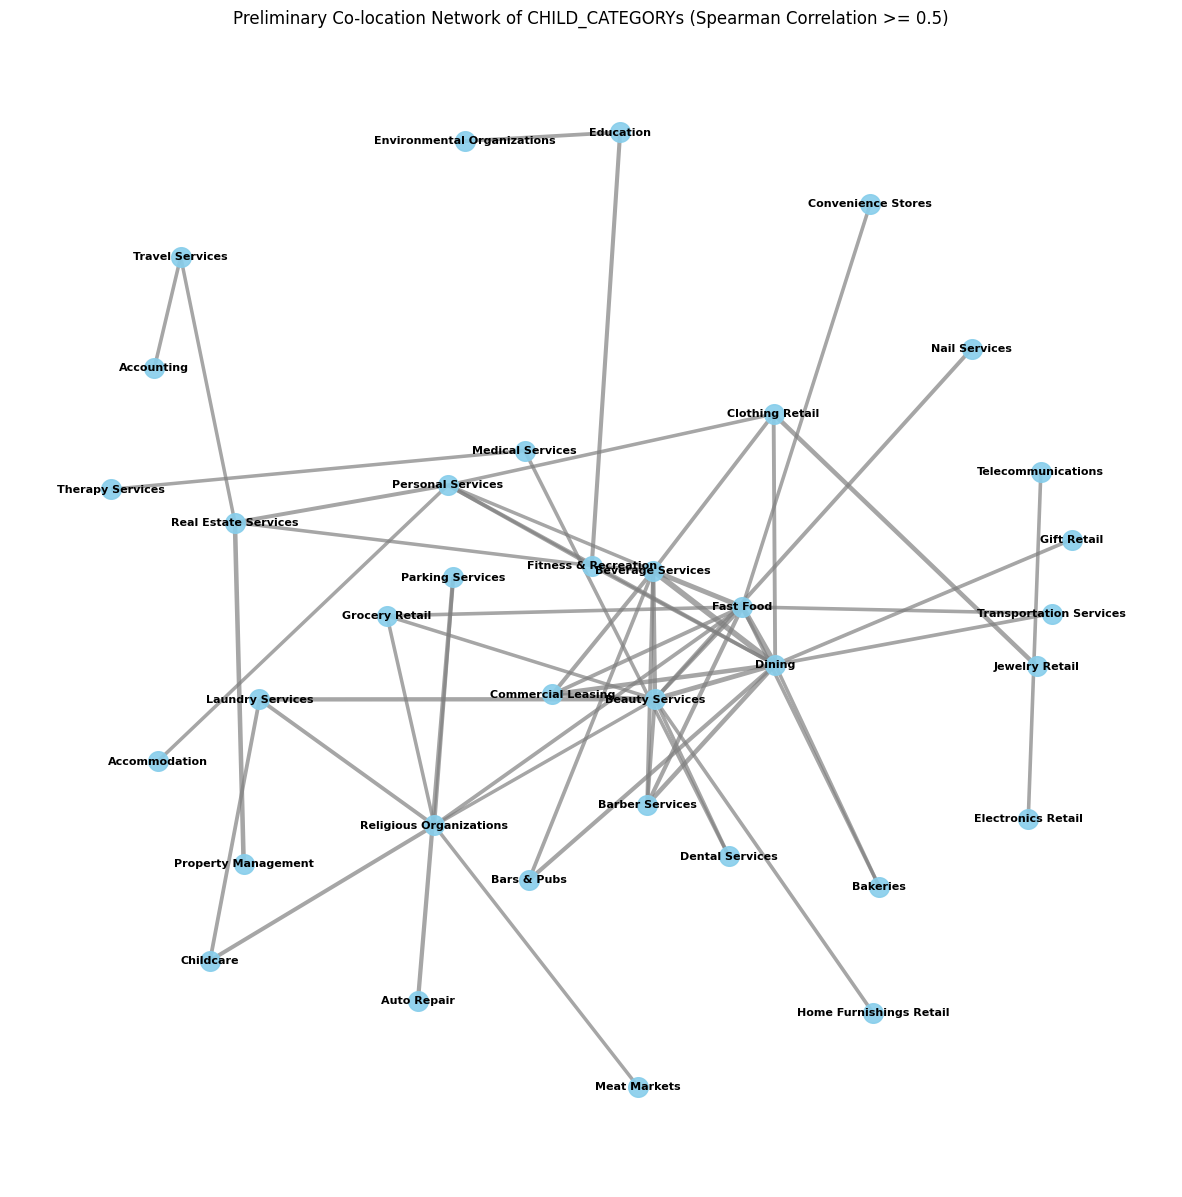

In [27]:
import networkx as nx
import matplotlib.pyplot as plt

# Create an empty graph
G = nx.Graph()

# Add nodes to the graph (all unique categories involved in significant correlations)
# First, collect all unique categories
all_categories = pd.concat([significant_strong_correlations_df['category_a'], significant_strong_correlations_df['category_b']]).unique()
G.add_nodes_from(all_categories)

# Add edges with correlation as weight
for index, row in significant_strong_correlations_df.iterrows():
    G.add_edge(row['category_a'], row['category_b'], weight=row['correlation'])

print(f"Co-location network created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

# Visualize the network
plt.figure(figsize=(15, 15))
pos = nx.spring_layout(G, k=0.8, iterations=50) # positions for all nodes

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=200, node_color='skyblue', alpha=0.9)

# Draw edges
edges = G.edges(data=True)
weights = [d['weight'] for u, v, d in edges]
nx.draw_networkx_edges(G, pos, edgelist=edges, width=[w * 5 for w in weights], alpha=0.7, edge_color='gray')

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

plt.title('Preliminary Co-location Network of CHILD_CATEGORYs (Spearman Correlation >= 0.5)')
plt.axis('off') # Hide axes
plt.show()


#### 2.2  Network Analysis

In [28]:
import networkx as nx
from community import community_louvain # Correct import for best_partition

# Apply the Louvain method for community detection
# The best_partition function returns a dictionary mapping nodes to their community IDs.
partition = community_louvain.best_partition(G, weight='weight')

print(f"Detected {len(set(partition.values()))} communities.")

# Calculate the modularity score. NetworkX has its own modularity function.
# Note: nx.community.modularity expects the partition as a list of sets or a dictionary mapping nodes to communities.
# partition.values() gives the community IDs for each node. We need to group nodes by their community ID.
communities = {} # To store nodes grouped by community ID
for node, comm_id in partition.items():
    if comm_id not in communities:
        communities[comm_id] = set()
    communities[comm_id].add(node)

# Convert the dictionary values to a list of sets for nx.community.modularity
modularity_score = nx.community.modularity(G, communities.values(), weight='weight')

print(f"Modularity Score: {modularity_score}")

Detected 6 communities.
Modularity Score: 0.4407510950272425


In [29]:
degree_centrality = nx.degree_centrality(G)

print("Degree Centrality calculated.")
display(pd.Series(degree_centrality).sort_values(ascending=False).head())

Degree Centrality calculated.


,0
Dining,0.342857
Beauty Services,0.314286
Fast Food,0.285714
Beverage Services,0.257143
Religious Organizations,0.200000


In [ ]:
betweenness_centrality = nx.betweenness_centrality(G, weight='weight')

print("Betweenness Centrality calculated.")
display(pd.Series(betweenness_centrality).sort_values(ascending=False).head())

Betweenness Centrality calculated.


,0
Personal Services,0.378824
Bars & Pubs,0.313725
Beverage Services,0.243137
Beauty Services,0.178824
Religious Organizations,0.109020
